<a href="https://colab.research.google.com/github/Ritik-Gupta-675/ML-LAB-6TH-SEM/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [23]:
# Helper function to calculate Euclidean distance
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KNeighborsClassifier:
    def __init__(self, n_neighbors=80):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Compute distances between x and all examples in the training set
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Sort by distance and return indices of the first k neighbors
        k_indices = np.argsort(distances)[:self.n_neighbors]

        # Extract the labels of the k nearest neighbor training samples
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return the most common class label
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]




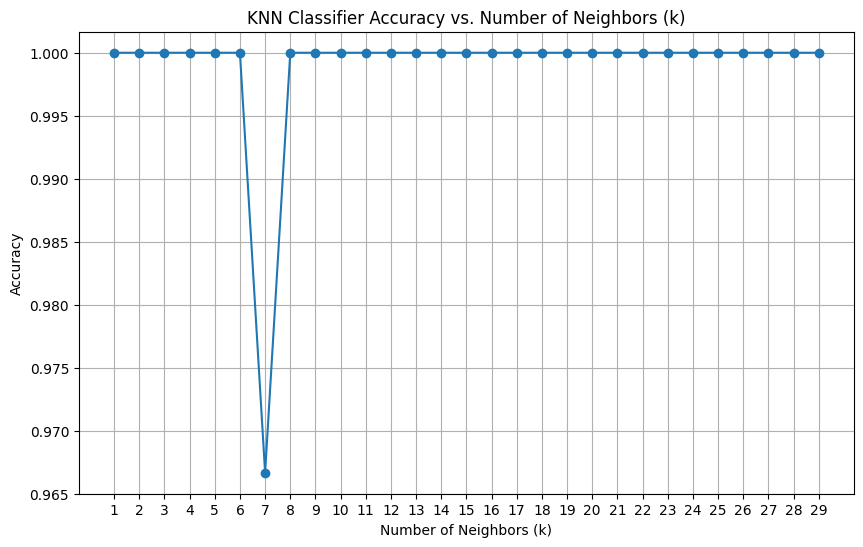

In [24]:
import matplotlib.pyplot as plt

# Define a range of k values to test
k_values = range(1, 30)
accuracies = []

for k in k_values:
    # Create a KNN classifier instance with the current k
    knn_cv = KNeighborsClassifier(n_neighbors=k)

    # Fit the model to the training data
    knn_cv.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred_cv = knn_cv.predict(X_test)

    # Evaluate the accuracy of the model
    accuracy_cv = accuracy_score(y_test, y_pred_cv)
    accuracies.append(accuracy_cv)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN Classifier Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values) # Ensure all k values are shown on the x-axis
plt.grid(True)
plt.show()

This plot shows how the model's accuracy changes as you vary the `n_neighbors` parameter. You can use this to identify an optimal `k` value for your model.

In [25]:
# --- Example Usage with Iris Dataset ---
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training KNN model...")
# Create a KNN classifier instance
knn = KNeighborsClassifier(n_neighbors=80)

# Fit the model to the training data
knn.fit(X_train, y_train)

print("Making predictions...")
# Make predictions on the test data
y_pred = knn.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nExample predictions (first 5 test samples):")
for i in range(5):
    print(f"  Actual: {y_test[i]}, Predicted: {y_pred[i]}")

Training KNN model...
Making predictions...
Model Accuracy: 0.6333

Example predictions (first 5 test samples):
  Actual: 1, Predicted: 1
  Actual: 0, Predicted: 0
  Actual: 2, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
